In [ ]:
# This code is developed to identify swim signals via StFT method.
# Import necessary libraries for short-time Fourier transform and signal processing
import numpy as np
from scipy.signal import stft
from zfish.utils import *

def process_signals(
    signal: np.ndarray, 
    fs: int = 6000,
    window_size: int = 512,
):
    """
    Process the input signal to identify swim signals using Short-Time Fourier Transform (STFT).

    Parameters:
    - signal: np.ndarray
        The input signal array.
    - fs: int
        Sampling frequency of the signal.
    - window_size: int
        Size of the window for STFT.
    """
    # Perform Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal, fs=fs, nperseg=window_size)
    magnitude = np.abs(Zxx)
    phase = np.angle(Zxx)
    
    return f, t, magnitude, phase

from zfish.local_path import f_formal
from io import import12chFlt

res = import12chFlt(f_formal['Ephys path'][51])
ch0 = res['fltCh0']
ch1 = res['fltCh1']

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
from umap import UMAP

f0, t0, mag0, phase0 = process_signals(ch0, window_size=256)
f1, t1, mag1, phase1 = process_signals(ch1, window_size=256)

mag = np.concatenate((mag0, mag1), axis=0).T
print(mag.shape, ch0.shape, ch1.shape)
vmax = np.max(ch0)
vmin = np.min(ch0)
norm_ch0 = np.abs(np.log(ch0 + 1e-8) - np.log(vmax + 1e-8)) / np.abs(np.log(vmax + 1e-8) - np.log(vmin + 1e-8))
ch0_subsampled = np.append(norm_ch0[::128], norm_ch0[-1])
vmax1 = np.max(ch1)
vmin1 = np.min(ch1)
norm_ch1 = np.abs(np.log(ch1 + 1e-8) - np.log(vmax1 + 1e-8)) / np.abs(np.log(vmax1 + 1e-8) - np.log(vmin1 + 1e-8))
ch1_subsampled = np.append(norm_ch1[::128], norm_ch1[-1])
c = np.stack([sns.color_palette("Blues", as_cmap=True)(ch0_subsampled), sns.color_palette("Blues", as_cmap=True)(ch1_subsampled)], axis=2)
c = np.max(c, axis=2)

UMAP_model = Isomap(n_neighbors=100, n_components=2)
reduced_data = UMAP_model.fit_transform(mag)

(9156, 258) (1171800,) (1171800,)


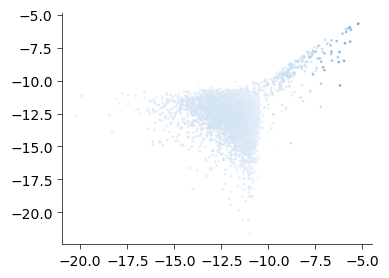

In [87]:
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.scatter(
    np.log(np.abs(reduced_data[:, 0])), 
    np.log(np.abs(reduced_data[:, 1])), 
    s=1, 
    alpha=0.5, 
    c=c
)
plt.show()